# Complement · Nombres complexos

[Obre aquest quadern a Google Colab](https://colab.research.google.com/github/mlacasa/1BATXILLERAT/blob/main/ComplexNumbers.ipynb)

**Matemàtiques · 1r de batxillerat**  
**Autoria: Dr. Lacasa-Cazcarra · Any 2026**

**Objectiu.** Operar amb nombres complexos i representar-ne el mòdul i l'argument correctament.

**Abans de començar:** àlgebra i trigonometria  
**Temps orientatiu:** 1–2 sessions. Hi ha activitats bàsiques i ampliacions opcionals.

**Funcionament.** Executa les cel·les en ordre, des del començament. Primer fes una predicció,
després experimenta i escriu una justificació. Els controls són opcionals: també pots
modificar els arguments de les funcions i executar-les. Les figures representen mostres
finites; les propietats infinites necessiten una demostració.

**Procedència.** Reelaboració de ComplexNumbers.ipynb. Complement independent de la completesa de ℝ.


In [1]:
import math
from fractions import Fraction
from decimal import Decimal, localcontext
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True,
                     "font.size": 11, "figure.dpi": 100})

def explora(funcio, **rangs):
    """Controls opcionals: la mateixa funció també es pot cridar directament."""
    # Conservem un exemple estàtic per als lectors sense controls interactius.
    funcio()
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Sense controls: executem els paràmetres per defecte. Pots canviar-los a la crida.")
        return None
    panell = widgets.interactive(funcio, **rangs)
    display(panell)
    return panell


## Ruta guiada per a 1r de batxillerat

**Pregunta de partida:** Multiplicar per i fa el nombre més gran o el fa girar?

**Al final ho has de poder explicar:** Veure la multiplicació complexa com un gir i una dilatació i connectar-ho amb el càlcul algebraic.

La primera lectura combina l'exemple resolt amb el **laboratori animat** i les preguntes
que l'acompanyen. Els apartats marcats com a ampliació formal aprofundeixen en el rigor;
no cal entendre tot el codi per interpretar la matemàtica.

Dedica 2 minuts a una predicció escrita, 8–10 minuts a experimentar i pausar,
i 5 minuts a justificar una conclusió amb càlculs. Després resol el repte amb dades noves.
L'animació té controls de reproducció, pausa i selecció de fotograma.
Si el visor no mostra HTML interactiu, el fotograma estàtic i la funció
`fotograma_laboratori(...)` permeten fer la mateixa activitat pas a pas després d'executar el codi.


## 1. Un nou problema d'existència
Cap nombre real té quadrat −1. Introduïm i amb $i^2=-1$ i escrivim $z=x+iy$.
Això amplia el sistema per resoldre equacions; és un problema diferent de completar ℚ.
La part imaginària és el nombre real y, mentre que el terme imaginari és iy.
En Python s'escriu `1j` per a i.


In [2]:
import cmath
z1, z2, z3 = 3+4j, 2+5j, -1+2j
print("Part real:", z1.real, "Part imaginària:", z1.imag)
print("Commutativa de la suma:", z1+z2 == z2+z1)
print("Associativa del producte:", (z1*z2)*z3 == z1*(z2*z3))
print("Distributiva:", z3*(z1+z2) == z3*z1+z3*z2)
print("Oposat:", -z1, "Conjugat:", z1.conjugate())
print("Invers:", 1/z1, "Producte pròxim a 1:", cmath.isclose(z1*(1/z1), 1))


Part real: 3.0 Part imaginària: 4.0
Commutativa de la suma: True
Associativa del producte: True
Distributiva: True
Oposat: (-3-4j) Conjugat: (3-4j)
Invers: (0.12-0.16j) Producte pròxim a 1: True


## 2. Mòdul, argument i invers
Per a z≠0, $|z|=\sqrt{x^2+y^2}$ i
$$z^{-1}=\frac{x-iy}{x^2+y^2}.$$
El zero no té invers ni un argument geomètric definit.
La fórmula $\arctan(y/x)$ sola no distingeix els quadrants i no serveix si x=0.
Usem `atan2(y,x)` o `cmath.phase(z)` per a z≠0.
L'argument està definit mòdul $2\pi$; el programa mostra un representant principal.


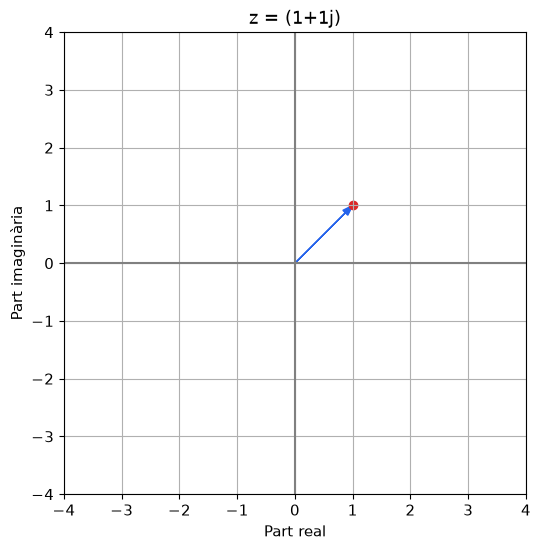

Mòdul: 1.41421
Argument: 0.785398 radians


interactive(children=(FloatSlider(value=1.0, description='real', max=3.0, min=-3.0, step=0.5), FloatSlider(val…

In [3]:
def dades_complex(z):
    z = complex(z)
    return abs(z), None if z == 0 else math.atan2(z.imag, z.real)

def pla_complex(real=1.0, imaginaria=1.0):
    z = complex(real, imaginaria)
    modul, argument = dades_complex(z)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.arrow(0, 0, real, imaginaria, length_includes_head=True,
             head_width=.12, color="#2563eb")
    ax.scatter([real], [imaginaria], color="#dc2626")
    ax.axhline(0, color="0.5"); ax.axvline(0, color="0.5")
    ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="Part real", ylabel="Part imaginària", title=f"z = {z}")
    ax.set_aspect("equal"); plt.show()
    print(f"Mòdul: {modul:.6g}")
    print("Argument no definit" if argument is None else f"Argument: {argument:.6g} radians")
panell = explora(pla_complex, real=(-3., 3., .5), imaginaria=(-3., 3., .5))


In [4]:
for z in (1+1j, -1+1j, -1-1j, 1-1j, 1j, 0j):
    print(z, "→", dades_complex(z))


(1+1j) → (1.4142135623730951, 0.7853981633974483)
(-1+1j) → (1.4142135623730951, 2.356194490192345)
(-1-1j) → (1.4142135623730951, -2.356194490192345)
(1-1j) → (1.4142135623730951, -0.7853981633974483)
1j → (1.0, 1.5707963267948966)
0j → (0.0, None)


## Laboratori animat · observa, atura i explica


### Multiplicar per i és fer un quart de volta

Prenem $z=2+i$. Com que $i^2=-1$,

$$i(2+i)=2i+i^2=-1+2i.$$

El punt (2,1) es transforma en (−1,2): un gir de 90° en sentit antihorari.
La distància a l'origen es manté: $\sqrt{2^2+1^2}=\sqrt{(-1)^2+2^2}=\sqrt5$.

| Multiplicació | Resultat | Coordenades |
|---|---|---|
| z | 2+i | (2,1) |
| iz | −1+2i | (−1,2) |
| i²z | −2−i | (−2,−1) |
| i³z | 1−2i | (1,−2) |
| i⁴z | 2+i | (2,1) |

L'animació mostra també els girs intermedis: multipliquem per
$w=\cos\theta+i\sin\theta$, de mòdul 1. L'esquerra mostra el gir; les barres de la dreta
són les parts real i imaginària del resultat, **no** dues distàncies sempre positives.

**Prediu** on serà el punt després de dos quarts de volta. **Pausa** a 90°, 180° i 270°
i comprova el resultat algebraic. La circumferència conserva el radi √5.


In [5]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def fotograma_laboratori(pas):
    """Mostra un estat quiet per poder llegir, dibuixar i prendre apunts."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=90)
    dibuixa_laboratori(pas, axes)
    fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .92))
    plt.show()

def anima_laboratori():
    """Animació HTML amb pausa i desplaçament manual; no necessita FFmpeg."""
    fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.7), dpi=80)
    def actualitza(pas):
        for ax in axes:
            ax.clear()
        dibuixa_laboratori(pas, axes)
        fig.suptitle(titol_laboratori, fontsize=14, weight="bold")
        fig.tight_layout(rect=(0, 0, 1, .92))
    animacio = FuncAnimation(fig, actualitza, frames=fotogrames_laboratori,
                             interval=700, repeat=False, cache_frame_data=False)
    try:
        contingut = animacio.to_jshtml(fps=1.5, default_mode="once")
    finally:
        plt.close(fig)
    return HTML(contingut)


In [6]:
titol_laboratori = "Multiplicar complexos: veure el gir i comprovar les coordenades"
fotogrames_laboratori = list(range(25))

def gira_complex(z, graus, escala=1):
    angle = math.radians(graus)
    w = escala*complex(math.cos(angle), math.sin(angle))
    return w, w*z

def dibuixa_laboratori(pas, axes):
    graus = 15*pas
    z = 2+1j
    w, producte = gira_complex(z, graus)
    ax, bx = axes
    t = np.linspace(0, 2*np.pi, 250)
    ax.plot(abs(z)*np.cos(t), abs(z)*np.sin(t), ":", color="0.6")
    ax.axhline(0, color="0.5", lw=.7)
    ax.axvline(0, color="0.5", lw=.7)
    for u, color, nom in [(z, "#2563eb", "z = 2+i"), (producte, "#ea580c", "w·z")]:
        ax.annotate("", (u.real, u.imag), (0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2))
        ax.scatter(u.real, u.imag, color=color, label=nom, s=50)
    ax.set(aspect="equal", xlim=(-2.7, 2.7), ylim=(-2.7, 2.7), xlabel="Part real", ylabel="Part imaginària",
           title=f"Gir: {graus}°; |w| = 1\n|w·z| = |z| ≈ {abs(producte):.5f}")
    ax.legend(loc="lower left", fontsize=8)
    bx.bar([0, 1], [producte.real, producte.imag], color=["#2563eb", "#ea580c"])
    bx.axhline(0, color="0.2")
    bx.set(xticks=[0, 1], xticklabels=["Part real", "Part imaginària"], ylim=(-2.7, 2.7),
           title=f"w ≈ {w.real:.3f} + ({w.imag:.3f})i\nw·z ≈ {producte.real:.3f} + ({producte.imag:.3f})i")
    bx.text(.5, .04, f"a²+b² = {abs(producte)**2:.3f}", transform=bx.transAxes, ha="center")


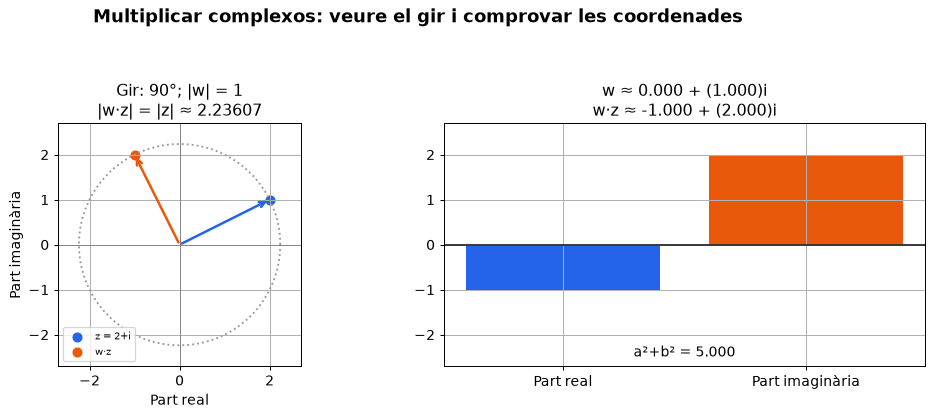

In [7]:
# Fotograma visible també quan no es reprodueix l'animació.
fotograma_laboratori(6)


**Ara reprodueix l'animació.** Fes servir la pausa i el control de fotograma per contrastar la teva predicció. Els valors numèrics dels títols formen part de l'explicació.


In [8]:
display(anima_laboratori())


### Compara abans de concloure

Compara z amb iz: contrasta les coordenades i el mòdul. Després compara 90° i 270°. Justifica els signes de les dues components, sense confondre una component negativa amb una distància negativa.

Tria dos estats amb els controls i prem **Compara els estats**. Llegeix les escales: algunes ampliacions del laboratori canvien els límits dels eixos. Justifica la comparació amb els nombres dels títols.


In [9]:
parella_comparacio = (0, 6)
etiquetes_comparacio = [f"Gir de {15*k}°" for k in fotogrames_laboratori]
preguntes_taller = [{'enunciat': "Quin és el resultat d'i(2+i)?", 'opcions': ['2+2i', '1+2i', '−1+2i'], 'correcta': 2, 'retorn': ['Aquest és el resultat de sumar i, no de multiplicar.', 'Recorda que i²=−1, no 1.', 'Correcte: 2i+i²=−1+2i.']}, {'enunciat': 'Multiplicar per 2i produeix...', 'opcions': ['Un gir de 90° i una duplicació del mòdul', 'Una traslació de dues unitats', 'Un gir de 180° sense canviar el mòdul'], 'correcta': 0, 'retorn': ['Correcte: el factor 2 dilata i el factor i gira un quart de volta.', 'Una traslació correspon a sumar, no a multiplicar.', 'El gir de 180° correspondria a multiplicar per −1.']}, {'enunciat': 'Per què el zero no té argument definit?', 'opcions': ['Perquè no té mòdul', "Perquè no determina cap direcció des de l'origen", 'Perquè és un nombre negatiu'], 'correcta': 1, 'retorn': ['El seu mòdul sí que està definit i val 0.', 'Correcte: qualsevol angle amb radi zero arriba al mateix punt.', "El zero no és negatiu; el problema és l'absència de direcció."]}]


In [10]:
def compara_estats(inicial, final):
    """Dos fotogrames simultanis; els eixos conserven el significat del laboratori."""
    if inicial not in fotogrames_laboratori or final not in fotogrames_laboratori:
        raise ValueError("Tria dos estats de fotogrames_laboratori.")
    fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), dpi=90)
    for fila, estat, lletra in [(0, inicial, "A"), (1, final, "B")]:
        dibuixa_laboratori(estat, axes[fila])
        for ax in axes[fila]:
            ax.set_title(lletra + " · " + ax.get_title(), fontsize=10)
    fig.suptitle("Comparació simultània: observa què canvia i què es conserva", fontsize=14, weight="bold")
    fig.tight_layout(rect=(0, 0, 1, .95), h_pad=3)
    plt.show()

def controls_comparacio():
    try:
        import ipywidgets as widgets
    except ImportError:
        print("Canvia els dos arguments de compara_estats(...) per fer una altra comparació.")
        return None
    opcions = list(zip(etiquetes_comparacio, fotogrames_laboratori))
    panell = widgets.interactive(compara_estats, {"manual": True, "manual_name": "Compara els estats"},
        inicial=widgets.Dropdown(options=opcions, value=parella_comparacio[0], description="Estat A:"),
        final=widgets.Dropdown(options=opcions, value=parella_comparacio[1], description="Estat B:"))
    display(panell)
    return panell

def feedback_resposta(numero, lletra):
    """Retorn per opció. Ex.: feedback_resposta(1, 'B'); no desa ni envia respostes."""
    if isinstance(numero, bool) or not isinstance(numero, int) or not 1 <= numero <= len(preguntes_taller):
        raise ValueError("El número de pregunta no és vàlid.")
    q = preguntes_taller[numero-1]
    lletra = str(lletra).strip().upper()
    lletres = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"[:len(q["opcions"])]
    if lletra not in lletres or len(lletra) != 1:
        raise ValueError("Tria una de les lletres de les opcions.")
    index = lletres.index(lletra)
    return {"correcte": index == q["correcta"], "explicacio": q["retorn"][index]}

def mostra_feedback(numero, lletra):
    resultat = feedback_resposta(numero, lletra)
    estat = "Resposta encertada" if resultat["correcte"] else "Revisa el raonament"
    display(Markdown(f"**Pregunta {numero} · {estat}.** {resultat['explicacio']}"))
    return resultat

def crea_autoavaluacio():
    try:
        import ipywidgets as widgets
        from html import escape
    except ImportError:
        print("Respon amb mostra_feedback(1, 'A'), canviant la pregunta i la lletra.")
        return None
    camps, selectors = [], []
    for numero, q in enumerate(preguntes_taller, 1):
        opcions = [("Tria una resposta", None)] + [
            (f"{chr(65+k)}. {text}", chr(65+k)) for k, text in enumerate(q["opcions"])]
        selector = widgets.Dropdown(options=opcions, value=None, layout=widgets.Layout(width="100%"))
        selectors.append(selector)
        camps.append(widgets.VBox([
            widgets.HTML(f"<b>{numero}. {escape(q['enunciat'])}</b>"), selector]))
    sortida = widgets.Output()
    boto = widgets.Button(description="Comprova i raona", button_style="info", layout=widgets.Layout(width="180px"))
    def comprova(_):
        with sortida:
            sortida.clear_output(wait=True)
            for numero, selector in enumerate(selectors, 1):
                if selector.value is None:
                    display(Markdown(f"**Pregunta {numero}:** encara has de triar una resposta."))
                else:
                    mostra_feedback(numero, selector.value)
    def canvi(_):
        sortida.clear_output()
    for selector in selectors:
        selector.observe(canvi, names="value")
    boto.on_click(comprova)
    panell = widgets.VBox(camps+[boto, sortida])
    display(panell)
    return {"panell": panell, "selectors": selectors, "boto": boto, "sortida": sortida}


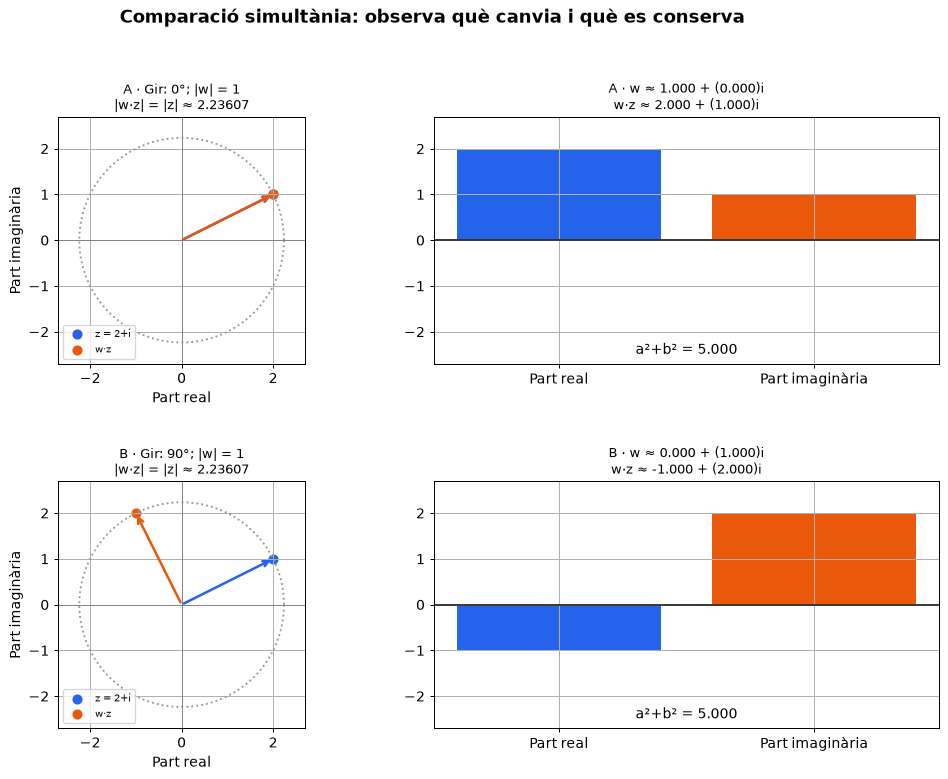

interactive(children=(Dropdown(description='Estat A:', options=(('Gir de 0°', 0), ('Gir de 15°', 1), ('Gir de …

In [11]:
compara_estats(*parella_comparacio)
panell_comparacio = controls_comparacio()


### Taller de Python · canvia una dada i explica l'efecte

Per al mateix z, compara sumar i, multiplicar per i i multiplicar per 2i. Calcula primer els tres resultats amb àlgebra. Després classifica cada transformació com a traslació, gir o gir amb dilatació.

**Fes-ho en tres passos:** escriu una predicció, modifica les dades indicades i contrasta el resultat. Acaba amb una explicació matemàtica; executar la cel·la és només una part de la tasca.


z: (2+1j); mòdul≈2.236068
z+i: (2+2j); mòdul≈2.828427
i·z: (-1+2j); mòdul≈2.236068
2i·z: (-2+4j); mòdul≈4.472136


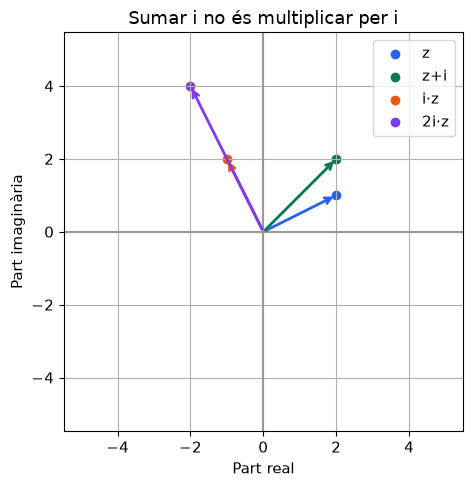

In [12]:
z_taller = 2+1j  # Prova també 3-2j.
transformacions = {"z": z_taller, "z+i": z_taller+1j,
                   "i·z": 1j*z_taller, "2i·z": 2j*z_taller}
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#2563eb", "#047857", "#ea580c", "#7c3aed"]
for (nom, z), color in zip(transformacions.items(), colors):
    print(f"{nom}: {z}; mòdul≈{abs(z):.6f}")
    ax.annotate("", (z.real, z.imag), (0, 0), arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.scatter(z.real, z.imag, color=color, label=nom)
abast = max(abs(z) for z in transformacions.values())+1
ax.axhline(0, color="0.6"); ax.axvline(0, color="0.6")
ax.set(aspect="equal", xlim=(-abast, abast), ylim=(-abast, abast),
       xlabel="Part real", ylabel="Part imaginària", title="Sumar i no és multiplicar per i")
ax.legend(); plt.tight_layout(); plt.show()


### Atura't i comprova què has entès

Tria una resposta per pregunta i escriu una justificació abans de comprovar-la. Si t'equivoques, llegeix el retorn i torna al gràfic per localitzar el malentès.

**1. Quin és el resultat d'i(2+i)?**

- A. 2+2i
- B. 1+2i
- C. −1+2i

**2. Multiplicar per 2i produeix...**

- A. Un gir de 90° i una duplicació del mòdul
- B. Una traslació de dues unitats
- C. Un gir de 180° sense canviar el mòdul

**3. Per què el zero no té argument definit?**

- A. Perquè no té mòdul
- B. Perquè no determina cap direcció des de l'origen
- C. Perquè és un nombre negatiu

Si no es mostren els controls, executa `mostra_feedback(1, 'B')`, canviant el número i la lletra. El retorn comprova l'opció; la justificació escrita s'ha de discutir a classe.


In [13]:
autoavaluacio = crea_autoavaluacio()


### Evidència final de l'aprenentatge

Completa aquestes frases amb un cas concret del taller:

1. **He canviat…**
2. **Esperava que… perquè…**
3. **El resultat ha estat…**
4. **Ara ho explico amb aquesta relació o propietat…**
5. **Un cas en què no puc generalitzar directament és…**

Torna a una pregunta que hagis corregit i explica què has canviat del teu raonament.


### Investiga i transfereix


1. Calcula $i(3-2i)$ i comprova'l amb un gir del punt (3,−2).
2. Compara $z+i$ amb $iz$ per a z=2+i. Quina operació trasllada? Quina gira?
3. Executa `gira_complex(2+1j, 90, escala=2)`. Com canvien el gir i el mòdul si multipliquem per 2i?
4. Per què el nombre 0 té mòdul, però no un argument definit?


### El teu raonament

Edita aquesta cel·la per deixar evidència del que has après.

- **Abans pensava que…**
- **He provat aquests valors…**
- **Al gràfic he observat…**
- **Ho justifico amb aquest càlcul o propietat…**
- **La meva conclusió i el seu límit són…**

No n'hi ha prou amb una captura: relaciona el dibuix, els nombres i l'explicació.


In [14]:
# Espai per al teu experiment: canvia l'índex i executa la cel·la.
# fotograma_laboratori(fotogrames_laboratori[0])
# Escriu aquí els càlculs del repte.


<details><summary>Comprovació: obre-la després d'intentar els reptes</summary>

i(3−2i)=2+3i. Sumar i trasllada una unitat cap amunt; multiplicar per i
gira 90°. Multiplicar per 2i gira 90° i duplica el mòdul: el resultat és −2+4i.
El zero té mòdul 0, però no determina cap direcció des de l'origen.

</details>

**Comprova el teu aprenentatge:** has interpretat els eixos i les unitats, justificat una predicció amb un càlcul i aplicat la idea a un cas nou? Una observació finita pot suggerir una propietat; una afirmació general necessita una justificació.


## 3. Fórmula de De Moivre
Si $z=r(\cos\theta+i\sin\theta)$, per a qualsevol enter n≥0:
$$z^n=r^n(\cos(n\theta)+i\sin(n\theta)).$$
Per a enters negatius cal z≠0. Comprovar un exemple numèric no demostra la fórmula
general; es pot demostrar per inducció amb les identitats de suma d'angles.


In [15]:
z, n = 1+1j, 5
r, theta = dades_complex(z)
polar = r**n * complex(math.cos(n*theta), math.sin(n*theta))
print("Potència directa:", z**n)
print("Forma trigonomètrica:", polar)
print("Coincidència dins de l'arrodoniment:", cmath.isclose(z**n, polar, rel_tol=1e-12, abs_tol=1e-12))


Potència directa: (-4-4j)
Forma trigonomètrica: (-4.000000000000003-4.000000000000001j)
Coincidència dins de l'arrodoniment: True


## Activitats
1. Per què la distributiva no és la propietat associativa?
2. Compara els arguments de 1+i i −1+i. Què donaria arctan(y/x)?
3. Troba l'invers de 3+4i a mà i comprova'l.
4. Explica per què ampliar ℝ a ℂ no significa que a ℝ li faltin límits de successions de Cauchy.

<details><summary>Comprovació</summary>

Els arguments són π/4 i 3π/4. L'invers és (3−4i)/25.
ℝ ja és complet; ℂ permet, entre altres coses, resoldre $z^2=-1$.
</details>


**Navegació:** [Índex i guia](README.md)
